<a href="https://colab.research.google.com/github/DD-SQUARED/Scientific-Data-Analysis-Python/blob/main/Tidal_Radius_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving NGC_6266.csv to NGC_6266 (4).csv


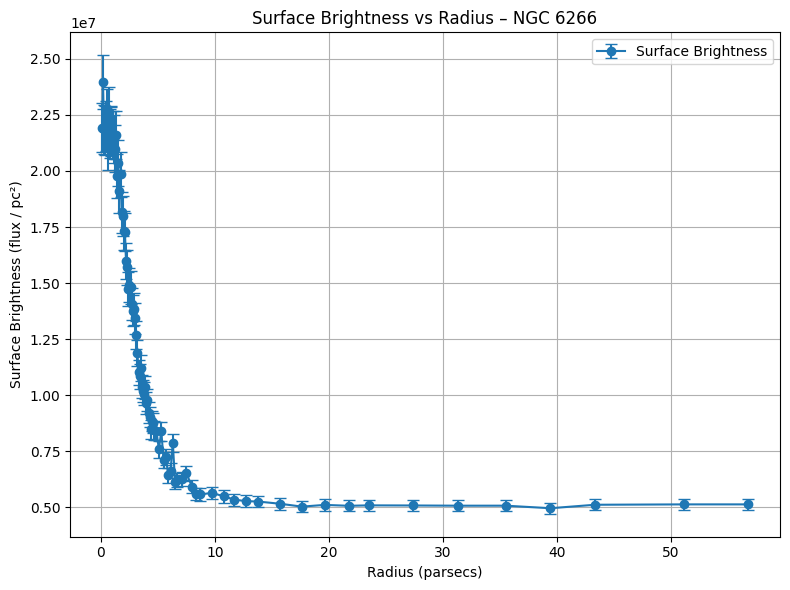

Estimated tidal radius: 8.00 parsecs


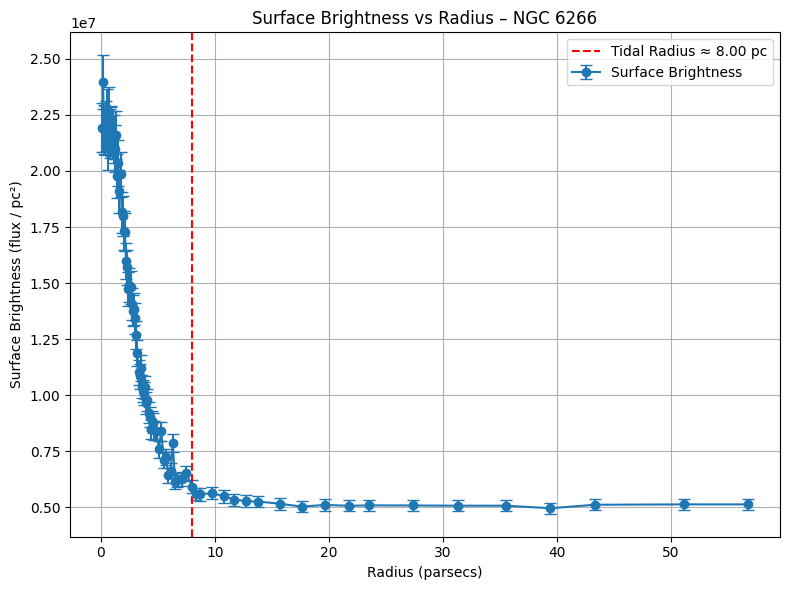

In [ ]:
# Stellar Cluster Surface Brightness and Tidal Radius Analysis

## Objective
To analyse surface brightness as a function of radius and estimate the tidal radius of a stellar cluster.

## Key Insights
- Surface brightness decreases with increasing radius
- Annular flux and area calculations enable accurate brightness estimation
- Tidal radius identified where brightness approaches background levels
- Results provide insight into cluster structure and extent

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Upload CSV using Google Colab uploader
from google.colab import files
uploaded = files.upload()

# Step 3: Load the uploaded CSV file
import io
filename = list(uploaded.keys())[0]  # Automatically gets the uploaded file name
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Step 4: Clean column names
df.columns = df.columns.str.strip()

# Step 5: Compute annular flux if not already provided
if 'Annulus_Flux' not in df.columns:
    df['Annulus_Flux'] = df['Flux'].diff().fillna(df['Flux'].iloc[0])

# Step 6: Calculate area of each annulus in parsec^2
area = []
for i in range(len(df)):
    if i == 0:
        area.append(np.pi * df.loc[i, 'Radius_parsecs']**2)
    else:
        r_outer = df.loc[i, 'Radius_parsecs']
        r_inner = df.loc[i - 1, 'Radius_parsecs']
        area.append(np.pi * (r_outer**2 - r_inner**2))
df['Annulus_Area_pc2'] = area

# Step 7: Calculate Surface Brightness
df['Surface_Brightness'] = df['Annulus_Flux'] / df['Annulus_Area_pc2']

# Step 8: Estimate errors (5%)
df['Flux_Error'] = 0.05 * df['Flux']
df['Annulus_Flux_Error'] = df['Flux_Error'].diff().abs().fillna(df['Flux_Error'].iloc[0])
df['Surface_Brightness_Error'] = df['Annulus_Flux_Error'] / df['Annulus_Area_pc2']

# Step 9: Plot Surface Brightness vs Radius
plt.figure(figsize=(8, 6))
plt.errorbar(df['Radius_parsecs'], df['Surface_Brightness'],
             yerr=df['Surface_Brightness_Error'],
             fmt='o-', capsize=4, label='Surface Brightness')

plt.xlabel('Radius (parsecs)')
plt.ylabel('Surface Brightness (flux / pc²)')
plt.title('Surface Brightness vs Radius – NGC 6266')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 10: Estimate tidal radius

# Define a background threshold as, for example, 10% of the maximum surface brightness
background_threshold = 0.25 * df['Surface_Brightness'].max()

# Find the first radius where surface brightness drops below threshold
tidal_radius_row = df[df['Surface_Brightness'] < background_threshold]

if not tidal_radius_row.empty:
    tidal_radius = tidal_radius_row['Radius_parsecs'].iloc[0]
    print(f"Estimated tidal radius: {tidal_radius:.2f} parsecs")
else:
    print("Tidal radius could not be estimated: surface brightness does not drop below threshold.")

# Optional: Plot tidal radius on the graph
plt.figure(figsize=(8, 6))
plt.errorbar(df['Radius_parsecs'], df['Surface_Brightness'],
             yerr=df['Surface_Brightness_Error'],
             fmt='o-', capsize=4, label='Surface Brightness')
if not tidal_radius_row.empty:
    plt.axvline(tidal_radius, color='r', linestyle='--', label=f'Tidal Radius ≈ {tidal_radius:.2f} pc')
plt.xlabel('Radius (parsecs)')
plt.ylabel('Surface Brightness (flux / pc²)')
plt.title('Surface Brightness vs Radius – NGC 6266')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
